# MÔ HÌNH B1: ZERO-SHOT VỚI QWEN2-VL-2B
**Mục tiêu:** Tải dataset, tải mô hình gốc Qwen2-VL-2B-Instruct, chạy thử Zero-shot và lưu mô hình cục bộ.  
**Hướng dẫn:** Bấm `Run All` hoặc chạy từng Cell theo thứ tự từ trên xuống dưới.


In [15]:
# Cell 1: Cài đặt thư viện (Bỏ comment nếu chạy trên Colab lần đầu)
# !pip install -q transformers accelerate datasets huggingface_hub

In [16]:
# Cell 2: TẢI VÀ GIẢI NÉN BỘ DỮ LIỆU OPENVIVQA
import os, zipfile, json
from huggingface_hub import hf_hub_download

os.makedirs("data/openvivqa/dev", exist_ok=True)

def download_and_extract(filename, extract_to):
    print(f"Đang tải {filename} từ HuggingFace...")
    file_path = hf_hub_download(repo_id="uitnlp/OpenViVQA-dataset", filename=filename, repo_type="dataset")
    if filename.endswith(".zip"):
        print(f"Đang giải nén {filename}...")
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
        print(f"Hoàn tất giải nén vào {extract_to}")
    else:
        import shutil
        shutil.copy(file_path, os.path.join(extract_to, filename))
        print(f"Đã lưu {filename} vào {extract_to}")

if not os.path.exists("data/openvivqa/dev/dev-images"):
    download_and_extract("dev-images.zip", "data/openvivqa/dev")

if not os.path.exists("data/openvivqa/vlsp2023_dev_data.json"):
    download_and_extract("vlsp2023_dev_data.json", "data/openvivqa")

print("Hoàn tất tải dataset!")

Hoàn tất tải dataset!


In [17]:
# Cell 3: ĐỌC DỮ LIỆU VÀ TẠO 5 MẪU TEST NGẪU NHIÊN
import json, random

print("Đang đọc tập dữ liệu Dev...")
with open("data/openvivqa/vlsp2023_dev_data.json", 'r', encoding='utf-8') as f:
    dev_data_json = json.load(f)

images_dict = dev_data_json.get("images", {})
annotations_dict = dev_data_json.get("annotations", {})

eval_samples = []
for ann_info in annotations_dict.values():
    img_id_str = str(ann_info["image_id"])
    img_filename = images_dict.get(img_id_str)
    if img_filename:
        full_path = os.path.join("data/openvivqa/dev/dev-images", img_filename)
        eval_samples.append({
            "image": full_path,
            "question": ann_info["question"],
            "answer": ann_info["answer"]
        })

random.seed(42)
test_samples = random.sample(eval_samples, min(5, len(eval_samples)))
print(f"Đã chuẩn bị {len(test_samples)} mẫu để test Zero-shot.")
for i, s in enumerate(test_samples):
    print(f"  [{i+1}] {s['question']}")

Đang đọc tập dữ liệu Dev...
Đã chuẩn bị 5 mẫu để test Zero-shot.
  [1] có bao nhiêu người đi vào chợ bằng xe máy ?
  [2] chương trình đang chiếu là chương trình gì ?
  [3] đây là gì ?
  [4] có bao nhiêu người đang ở trong cửa hàng ?
  [5] dòng chữ stanley có màu gì ?


In [18]:
# Cell 4: TẢI MÔ HÌNH B1 VÀ PROCESSOR
import torch
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration
from PIL import Image

model_id = "Qwen/Qwen2-VL-2B-Instruct"
print(f"Đang tải Processor của {model_id}...")
processor = AutoProcessor.from_pretrained(model_id, max_pixels=313600)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Thiết bị sử dụng: {device.upper()}")
print(f"Đang tải mô hình B1 gốc (Zero-shot)...")

model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id,
    device_map={"": device},
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
)
print("Hoàn tất tải mô hình B1!")

Đang tải Processor của Qwen/Qwen2-VL-2B-Instruct...
Thiết bị sử dụng: CUDA
Đang tải mô hình B1 gốc (Zero-shot)...


Loading weights: 100%|██████████| 729/729 [00:02<00:00, 281.84it/s]


Hoàn tất tải mô hình B1!


--- KET QUA DU DOAN ZERO-SHOT ---
Mau 1: có bao nhiêu người đi vào chợ bằng xe máy ?
  GT: có hai người đang đi vào chợ bằng xe máy
  B1: Xe máy chiếm khoảng 30% tổng số người đi vào chợ.
Mau 2: chương trình đang chiếu là chương trình gì ?
  GT: chương trình đang chiếu là chương trình thời sự
  B1: Chương trình đang chiếu là "Thời sự" trên VTV4.
Mau 3: đây là gì ?
  GT: đây là phòng giao dịch số 1 của pvi tây nam
  B1: Hình ảnh này là một bảng hiệu của Tổng Công ty Bảo hiểm PVI tại Tây Nam, với địa chỉ ở số 51 Trần Đại
Mau 4: có bao nhiêu người đang ở trong cửa hàng ?
  GT: có một người đang ở trong cửa hàng
  B1: Cửa hàng có khoảng 3 người đang ở trong đó.
Mau 5: dòng chữ stanley có màu gì ?
  GT: có màu xanh dương
  B1: Stanley dòng chữ có màu xanh lá cây.


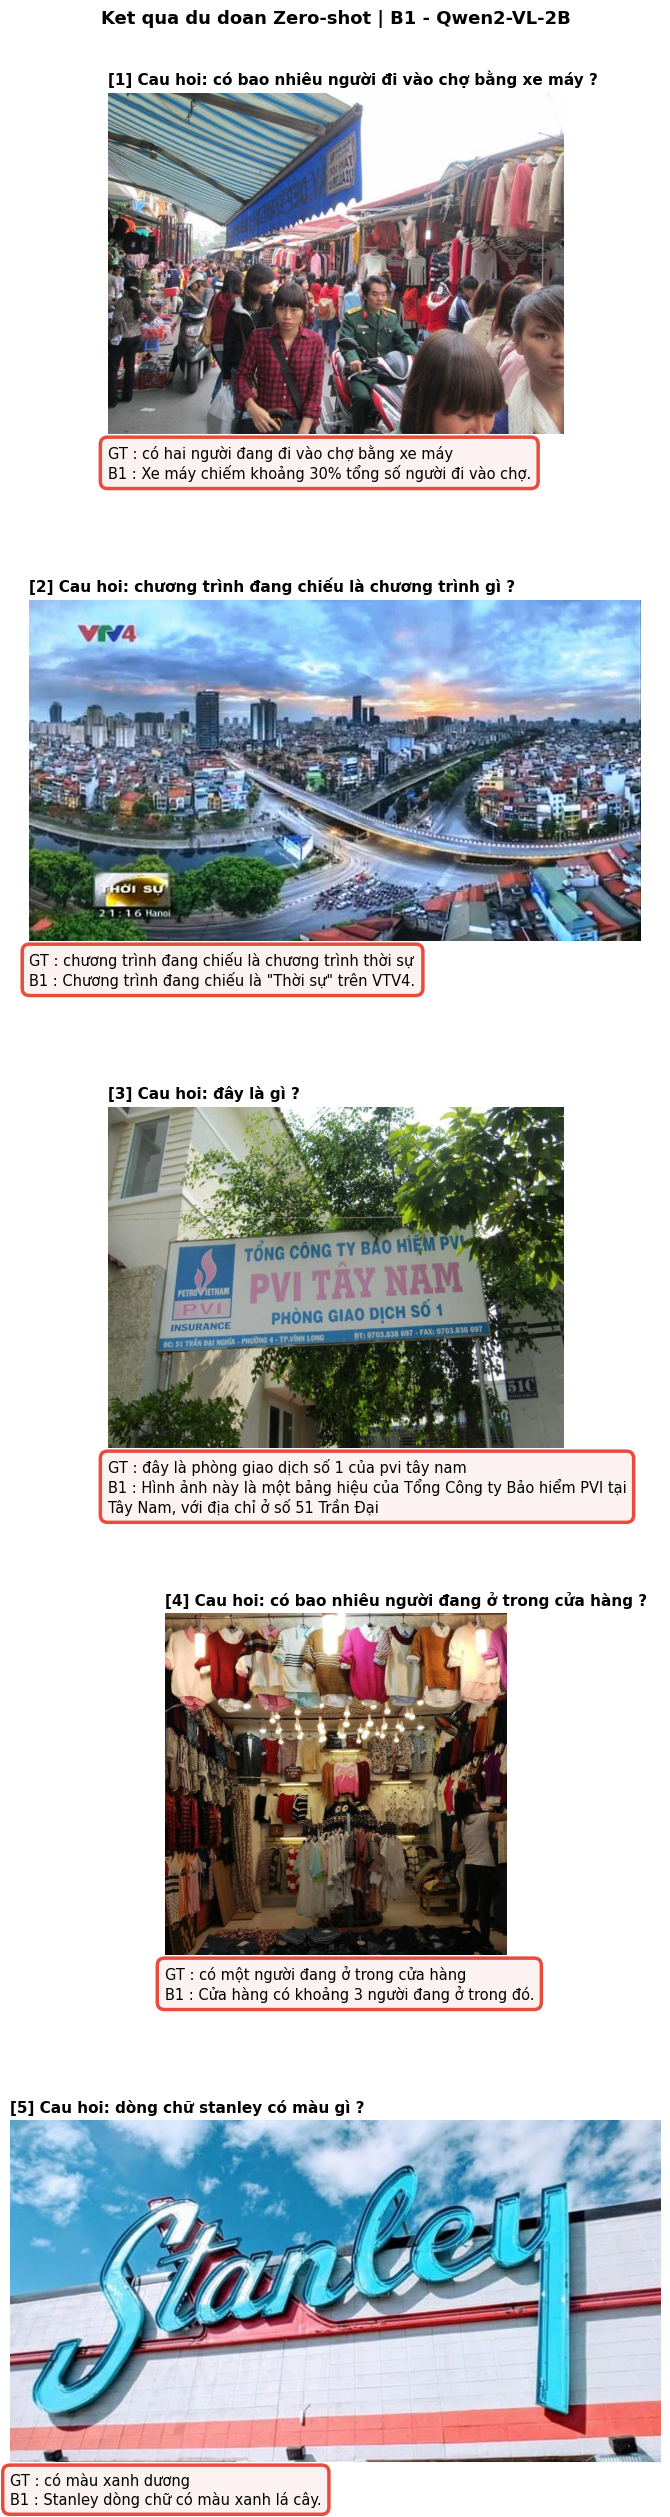

Da luu: b1_zeroshot_results.png


In [21]:
# Cell 5: CHẠY ZERO-SHOT INFERENCE + HIỂN THỊ ẢNH
import matplotlib.pyplot as plt
import matplotlib as mpl
import textwrap

# Fix font tiếng Việt trên Windows/Colab
# Ưu tiên font có dấu tiếng Việt
for font_candidate in ["DejaVu Sans", "Arial", "Tahoma", "Liberation Sans"]:
    try:
        mpl.font_manager.findfont(font_candidate, fallback_to_default=False)
        mpl.rcParams["font.family"] = font_candidate
        break
    except: pass

SYSTEM_PROMPT = (
    "Bạn là trợ lý trả lời câu hỏi về hình ảnh bằng tiếng Việt. "
    "Hãy trả lời NGẮN GỌN, tối đa 1-2 câu, chỉ nêu thông tin cốt lõi."
)

n = len(test_samples)
fig, axes = plt.subplots(n, 1, figsize=(10, n * 5))
if n == 1: axes = [axes]

print("--- KET QUA DU DOAN ZERO-SHOT ---")
for i, (sample, ax) in enumerate(zip(test_samples, axes)):
    # ── Inference ────────────────────────────────────────────────
    try:
        image = Image.open(sample["image"]).convert("RGB")
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": [
                {"type": "image"},
                {"type": "text", "text": sample["question"]}
            ]}
        ]
        text   = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[image], padding=True, return_tensors="pt")
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        with torch.no_grad():
            generated_ids = model.generate(
                **inputs, max_new_tokens=30, do_sample=False, repetition_penalty=1.1)
        input_len  = inputs["input_ids"].shape[1]
        output_text = processor.batch_decode(
            generated_ids[:, input_len:],
            skip_special_tokens=True, clean_up_tokenization_spaces=False
        )[0].strip()
    except Exception as e:
        output_text = str(e)
        image = Image.new("RGB", (224, 224), (200, 200, 200))

    gt      = sample["answer"]
    correct = output_text.strip().lower() == gt.strip().lower()

    print(f"Mau {i+1}: {sample['question']}")
    print(f"  GT: {gt}")
    print(f"  B1: {output_text}")

    # ── Vẽ ảnh ───────────────────────────────────────────────────
    ax.imshow(image)
    ax.axis("off")

    # Câu hỏi làm tiêu đề (KHÔNG dùng emoji)
    q_wrap = "\n".join(textwrap.wrap(f"[{i+1}] Cau hoi: {sample['question']}", width=65))
    ax.set_title(q_wrap, fontsize=11, fontweight="bold", pad=6, loc="left")

    # Caption GT + B1 — KHÔNG dùng fontfamily monospace để tránh lỗi tiếng Việt
    border_color = "#27ae60" if correct else "#e74c3c"
    bg_color     = "#eafaf1" if correct else "#fdf2f2"

    gt_line   = "\n".join(textwrap.wrap(f"GT : {gt}", width=70))
    pred_line = "\n".join(textwrap.wrap(f"B1 : {output_text}", width=70))
    caption   = f"{gt_line}\n{pred_line}"

    ax.text(0.0, -0.03, caption,
            transform=ax.transAxes,
            fontsize=10.5,
            verticalalignment="top",
            bbox=dict(
                boxstyle="round,pad=0.5",
                facecolor=bg_color,
                edgecolor=border_color,
                linewidth=2.5
            ))

plt.suptitle("Ket qua du doan Zero-shot | B1 - Qwen2-VL-2B",
             fontsize=13, fontweight="bold", y=1.005)
plt.tight_layout(h_pad=5.5)
plt.savefig("b1_zeroshot_results.png", dpi=130,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Da luu: b1_zeroshot_results.png")

In [20]:
# Cell 6: LƯU MÔ HÌNH B1 CỤC BỘ
save_path = "./qwen2vl_b1_base"
print(f"Đang lưu mô hình và processor vào {save_path}...")
processor.save_pretrained(save_path)
model.save_pretrained(save_path)
print("Hoàn tất lưu mô hình B1!")

Đang lưu mô hình và processor vào ./qwen2vl_b1_base...


Writing model shards: 100%|██████████| 1/1 [00:29<00:00, 29.63s/it]

Hoàn tất lưu mô hình B1!
